# EV Charging Sessions — Exploratory Data Analysis

This notebook is the first step of the **EV Charging Intelligence & Optimization
Platform**. Before any model is trained, we need to know what the raw data actually
contains: how big it is, what each column means, which values are missing, and — most
importantly for this dataset — how internally consistent the measurements are.

The dataset is a single CSV of **1,320 EV charging sessions** spanning
2024-01-01 to 2024-02-24. It is synthetic, published for practising machine-learning
workflows, and it was generated column by column with little cross-column consistency.
That last point drives most of this notebook: a large fraction of rows break basic
charging physics (energy larger than the battery, state of charge going *down* while
charging, a reported duration that disagrees with the timestamps). We measure that
damage carefully here and carry a set of per-row **validation flags** forward, rather
than silently dropping rows or "fixing" numbers we cannot actually recover.

## Contents

1. **Loading Data**
2. **Basic Data Exploration** — shape, types, missing values, duplicates, uniqueness, ranges
3. **Areas to Fix** — the concrete problems found
4. **Data Preprocessing** — renaming, typing, derived columns, missing-value policy, validation flags
5. **Data Analysis** — charging volume, timing, energy, duration, cost, location, segments, correlations
6. **Conclusion** — insights, suggestions, next steps

## 1. Loading Data

We load the raw CSV exactly as delivered. Everything after this point is inspection and
cleaning that we can trace back to a specific problem in the file.

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)

In [2]:
# Load DataFrame
file = "../data/raw/ev_charging_patterns.csv"
df = pd.read_csv(file)

## 2. Basic Data Exploration

In [3]:
# Show rows and columns count
print(f"Rows count: {df.shape[0]}\nColumns count: {df.shape[1]}")

Rows count: 1320
Columns count: 20


In [4]:
df.head()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler


In [5]:
df.tail()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
1315,User_1316,Nissan Leaf,100.000000,Station_57,New York,2024-02-24 19:00:00,2024-02-24 20:30:00,42.011654,1.426444,5.895475,22.081164,Evening,Sunday,39.204102,83.915952,239.601075,1.919655,7.0,DC Fast Charger,Commuter
1316,User_1317,BMW i3,100.000000,Station_40,New York,2024-02-24 20:00:00,2024-02-24 20:44:00,68.185853,3.238212,18.388012,5.067806,Evening,Tuesday,31.456375,93.096461,164.376022,34.029775,4.0,Level 2,Casual Driver
1317,User_1318,Nissan Leaf,100.000000,Station_374,New York,2024-02-24 21:00:00,2024-02-24 23:03:00,18.895102,3.267122,45.482066,37.255002,Evening,Tuesday,71.903081,78.678879,226.519258,20.358761,5.0,DC Fast Charger,Commuter
1318,User_1319,Chevy Bolt,85.000000,Station_336,San Francisco,2024-02-24 22:00:00,2024-02-24 23:20:00,13.756252,2.754527,38.148183,39.046146,Afternoon,Sunday,76.187997,65.926573,291.494076,24.134598,5.0,Level 2,Commuter
1319,User_1320,Nissan Leaf,120.447195,Station_128,Los Angeles,2024-02-24 23:00:00,2024-02-24 23:56:00,63.652570,3.740970,33.704226,10.863674,Evening,Monday,59.338076,56.692439,14.449236,-6.966593,5.0,DC Fast Charger,Commuter


### Check Data Types

In [6]:
# Show data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   User ID                                   1320 non-null   object 
 1   Vehicle Model                             1320 non-null   object 
 2   Battery Capacity (kWh)                    1320 non-null   float64
 3   Charging Station ID                       1320 non-null   object 
 4   Charging Station Location                 1320 non-null   object 
 5   Charging Start Time                       1320 non-null   object 
 6   Charging End Time                         1320 non-null   object 
 7   Energy Consumed (kWh)                     1254 non-null   float64
 8   Charging Duration (hours)                 1320 non-null   float64
 9   Charging Rate (kW)                        1254 non-null   float64
 10  Charging Cost (USD)                 

Reading the output:

* `User ID`, `Vehicle Model`, `Charging Station ID`, `Charging Station Location`,
  `Time of Day`, `Day of Week`, `Charger Type` and `User Type` are stored as strings
  (`object`).
* `Charging Start Time` and `Charging End Time` are also strings — they should be
  `datetime64`.
* Every measurement column (`Battery Capacity (kWh)`, `Energy Consumed (kWh)`,
  `Charging Duration (hours)`, `Charging Rate (kW)`, `Charging Cost (USD)`, both
  `State of Charge` columns, `Distance Driven ...`, `Temperature (°C)`,
  `Vehicle Age (years)`) is a float.
* `Energy Consumed (kWh)`, `Charging Rate (kW)` and `Distance Driven ...` have fewer
  non-null entries than the row count, so they carry missing values.

One header, `Temperature (°C)`, contains a non-ASCII degree sign that is stored as a raw
Latin-1 byte. That makes the exact column name fragile to match in code.

### Check Missing Data

In [7]:
# Print percentage of missing values
missing_percent = df.isna().mean().sort_values(ascending=False)
print('---- Percentage of Missing Values (%) -----')
if missing_percent.sum():
    print(missing_percent[missing_percent > 0] * 100)
else:
    print('None')

---- Percentage of Missing Values (%) -----
Charging Rate (kW)                          5.0
Distance Driven (since last charge) (km)    5.0
Energy Consumed (kWh)                       5.0
dtype: float64


Three columns are missing exactly **66 values each (5.0%)**: `Energy Consumed (kWh)`,
`Charging Rate (kW)` and `Distance Driven (since last charge) (km)`. No other column has
gaps. Whether the same rows are missing across the three is worth checking before we
decide on a policy.

In [8]:
# Do the three columns go missing together, or independently?
missing_cols = ["Energy Consumed (kWh)", "Charging Rate (kW)",
                "Distance Driven (since last charge) (km)"]
mask = df[missing_cols].isna()
print("rows missing at least one:", mask.any(axis=1).sum())
print("rows missing all three  :", mask.all(axis=1).sum())
mask.value_counts()

rows missing at least one: 189
rows missing all three  : 0


Energy Consumed (kWh)  Charging Rate (kW)  Distance Driven (since last charge) (km)
False                  False               False                                       1131
                       True                False                                         62
                       False               True                                          60
True                   False               False                                         58
                                           True                                           5
                       True                False                                          3
False                  True                True                                           1
Name: count, dtype: int64

The gaps are **independent** — 189 rows are missing at least one of the three, only a
handful (if any) are missing more than one. That rules out a single "bad export" batch
and points to per-column dropout, which an imputation approach can handle.

### Check for Duplicate Rows

In [9]:
# Show number of duplicated rows
print(f"No. of entirely duplicated rows: {df.duplicated().sum()}")

# Show duplicated rows
df[df.duplicated()]

No. of entirely duplicated rows: 0


,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type


No fully duplicated rows. Given that `User ID` is unique per row (checked next), exact
duplicates were never likely, but it is worth confirming.

### Check Uniqueness of Data

In [10]:
# Print the percentage similarity of values (the lower %, the better)
num_unique = df.nunique().sort_values()
print('---- Percentage Similarity of Values (%) -----')
print(100 / num_unique)

---- Percentage Similarity of Values (%) -----
Charger Type                                33.333333
User Type                                   33.333333
Time of Day                                 25.000000
Vehicle Model                               20.000000
Charging Station Location                   20.000000
Day of Week                                 14.285714
Vehicle Age (years)                          0.877193
Battery Capacity (kWh)                       0.680272
Charging Station ID                          0.216450
Charging Rate (kW)                           0.079745
Energy Consumed (kWh)                        0.079745
Distance Driven (since last charge) (km)     0.079745
Charging End Time                            0.076394
Charging Cost (USD)                          0.075758
Charging Start Time                          0.075758
User ID                                      0.075758
State of Charge (End %)                      0.075758
State of Charge (Start %)          

* `Charger Type` and `User Type` take 3 values; `Vehicle Model`, `Charging Station
  Location` and `Time of Day` take 4–5; `Day of Week` takes 7. These are the categorical
  fields.
* `User ID` has **1,320 unique values for 1,320 rows** — exactly one charging session
  per user. This is the single most important structural fact in the dataset: any
  "per-user behaviour" analysis is really per-*session* analysis, because there is no
  second session to aggregate.
* `Charging Station ID` has **462 unique values** — about 2.8 sessions per station.
  Per-station demand forecasting would be far too sparse to be credible, so demand work
  later happens at the network and location level.
* The continuous measurements are almost entirely unique, as expected for float readings.

### Check Data Range

In [11]:
# Print summary statistics
df.describe(include='all')

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
count,1320,1320,1320.000000,1320,1320,1320,1320,1254.000000,1320.000000,1254.000000,1320.000000,1320,1320,1320.000000,1320.000000,1254.000000,1320.000000,1320.000000,1320,1320
unique,1320,5,NaN,462,5,1320,1309,NaN,NaN,NaN,NaN,4,7,NaN,NaN,NaN,NaN,NaN,3,3
top,User_1320,Tesla Model 3,NaN,Station_108,Los Angeles,2024-02-24 23:00:00,2024-01-06 18:48:00,NaN,NaN,NaN,NaN,Evening,Saturday,NaN,NaN,NaN,NaN,NaN,Level 1,Commuter
freq,1,280,NaN,9,297,1,2,NaN,NaN,NaN,NaN,362,205,NaN,NaN,NaN,NaN,NaN,459,476
mean,NaN,NaN,74.534692,NaN,NaN,NaN,NaN,42.642894,2.269377,25.963003,22.551352,NaN,NaN,49.130012,75.141590,153.596788,15.263591,3.612843,NaN,NaN
std,NaN,NaN,20.626914,NaN,NaN,NaN,NaN,22.411705,1.061037,14.011326,10.751494,NaN,NaN,24.074134,17.080580,86.004987,14.831216,2.309824,NaN,NaN
min,NaN,NaN,1.532807,NaN,NaN,NaN,NaN,0.045772,0.095314,1.472549,0.234317,NaN,NaN,2.325959,7.604224,0.862361,-10.724770,0.000000,NaN,NaN
25%,NaN,NaN,62.000000,NaN,NaN,NaN,NaN,23.881193,1.397623,13.856583,13.368141,NaN,NaN,27.786903,62.053266,79.445335,2.800664,2.000000,NaN,NaN
50%,NaN,NaN,75.000000,NaN,NaN,NaN,NaN,42.691405,2.258136,25.603799,22.076360,NaN,NaN,48.241771,75.682496,152.259867,14.630846,4.000000,NaN,NaN
75%,NaN,NaN,85.000000,NaN,NaN,NaN,NaN,61.206218,3.112806,37.502998,31.646044,NaN,NaN,69.277921,88.201370,226.073284,27.981810,6.000000,NaN,NaN


Several ranges are physically impossible and need flagging:

* **`Battery Capacity (kWh)`** runs from **1.5 to 193**. Real EV packs in this set of
  five models sit roughly between 40 and 100 kWh, so both tails are wrong.
* **`Temperature (°C)`** reaches **73 °C** and dips to **-11 °C**. The upper value is not
  an ambient temperature anywhere on Earth.
* **`State of Charge (Start %)` / `(End %)`** fall outside the 0–100 range on 32 rows,
  some far outside.
* **`Charging Duration (hours)`** has a mean near 2.2 h but, as we will see, barely
  correlates with the actual `End − Start` interval.
* `Energy Consumed (kWh)` has a maximum well above the *median* battery capacity, which
  foreshadows the "energy exceeds capacity" problem.

## 3. Areas to Fix

**Data Types**

* `Charging Start Time` and `Charging End Time` are strings; convert to `datetime64`.
* All 20 headers are long and contain spaces, units and a non-ASCII byte; rename to
  short `snake_case`.
* `Charger Type` has a natural speed order (Level 1 < Level 2 < DC Fast Charger) that a
  plain string throws away; keep an ordinal code alongside it.

**Missing Data**

* 66 missing values each in `Energy Consumed (kWh)`, `Charging Rate (kW)` and
  `Distance Driven (since last charge) (km)`, dropping out independently. Policy: keep
  the rows, keep the `NaN`s in the cleaned file, and let each downstream model drop a row
  only when *its own target* is missing and impute predictors itself.

**Duplicate Rows**

* None found. No action.

**Uniqueness of Data**

* One session per user → treat behavioural analysis as session-level, not user-level.
* ~2.8 sessions per station → forecast demand at network / location level, not station.
* `Time of Day` and `Day of Week` are categorical restatements of the timestamp, but
  they do **not** agree with it (shown in Data Analysis). Derive our own calendar
  features from the timestamps and keep the originals only with a `_reported` suffix.

**Data Range**

* `Battery Capacity (kWh)` outside ~10–150: flag.
* `Temperature (°C)` outside -30–60: flag.
* `State of Charge` outside 0–100: flag.
* `Energy Consumed` greater than `Battery Capacity`: flag.
* Reported `Charging Duration` far from `End − Start`: flag.
* `Charging Rate × Duration` far from `Energy Consumed`: flag.
* SOC-implied energy far from `Energy Consumed`: flag.

We **flag** rather than drop: the flags become the training signal for the anomaly
module in Phase 2, and dropping ~70% of rows (the duration-mismatch rate) would leave
almost nothing to model.

## 4. Data Preprocessing

Each fix below is applied and then checked with an `assert`. The same steps, in the same
order, are packaged in `evcharging.data.load_raw` and `evcharging.features.build_features`
so the notebooks and the production pipeline cannot drift apart. We import those at the
end of this section to confirm they reproduce what we did by hand.

### Rename Columns

We map every header to a short `snake_case` name. Two timestamp-derived categoricals,
`Time of Day` and `Day of Week`, get a `_reported` suffix because we will compute our own
versions from the timestamps and need to keep them distinct. The `Temperature` header is
matched by prefix rather than by its exact bytes.

In [12]:
# Rename columns
columns_to_rename = {
    "User ID": "user_id",
    "Vehicle Model": "vehicle_model",
    "Battery Capacity (kWh)": "battery_capacity_kwh",
    "Charging Station ID": "station_id",
    "Charging Station Location": "location",
    "Charging Start Time": "start_time",
    "Charging End Time": "end_time",
    "Energy Consumed (kWh)": "energy_kwh",
    "Charging Duration (hours)": "duration_hours_reported",
    "Charging Rate (kW)": "charging_rate_kw",
    "Charging Cost (USD)": "cost_usd",
    "Time of Day": "time_of_day_reported",
    "Day of Week": "day_of_week_reported",
    "State of Charge (Start %)": "soc_start_pct",
    "State of Charge (End %)": "soc_end_pct",
    "Distance Driven (since last charge) (km)": "distance_km",
    "Vehicle Age (years)": "vehicle_age_years",
    "Charger Type": "charger_type",
    "User Type": "user_type",
}
df.rename(columns=columns_to_rename, inplace=True)

# The temperature header holds a raw 0xB0 byte; match it by prefix.
temp_col = [c for c in df.columns if c.startswith("Temperature")][0]
df.rename(columns={temp_col: "temperature_c"}, inplace=True)

In [13]:
# Verify columns are renamed
df.columns

Index(['user_id', 'vehicle_model', 'battery_capacity_kwh', 'station_id',
       'location', 'start_time', 'end_time', 'energy_kwh',
       'duration_hours_reported', 'charging_rate_kw', 'cost_usd',
       'time_of_day_reported', 'day_of_week_reported', 'soc_start_pct',
       'soc_end_pct', 'distance_km', 'temperature_c', 'vehicle_age_years',
       'charger_type', 'user_type'],
      dtype='object')

In [14]:
# Verify: no leftover original-style headers, and the key new names exist
assert not any(" " in c for c in df.columns)
assert {"start_time", "end_time", "temperature_c", "energy_kwh"} <= set(df.columns)

### Changing Data Types

The two timestamp columns are parsed to `datetime64`. Pandas reads this ISO-8601 format
without a `format=` string. We do not touch the numeric columns — `read_csv` already
typed them as floats, and the out-of-range values are real data to be flagged, not parse
errors.

In [15]:
# Convert the timestamp columns to datetime
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])

In [16]:
# Verify conversion
import pandas.api.types as ptypes
assert ptypes.is_datetime64_any_dtype(df["start_time"])
assert ptypes.is_datetime64_any_dtype(df["end_time"])
df[["start_time", "end_time"]].dtypes

start_time    datetime64[ns]
end_time      datetime64[ns]
dtype: object

### Feature Engineering / Transformation

> **True vs reported duration**
>
> The file has a `Charging Duration (hours)` column, but it was generated separately from
> the timestamps. We compute the duration we can actually trust — `end_time − start_time`
> — call it `duration_hours`, and keep the file's version as `duration_hours_reported`
> for comparison.

In [17]:
# True session length from the timestamps, in hours
df["duration_hours"] = (df["end_time"] - df["start_time"]).dt.total_seconds() / 3600
df["duration_hours"].describe()

count    1320.000000
mean        2.225240
std         1.008414
min         0.500000
25%         1.379167
50%         2.183333
75%         3.083333
max         3.983333
Name: duration_hours, dtype: float64

In [18]:
# Every session must have a strictly positive real duration
assert (df["duration_hours"] > 0).all()

How badly does the reported duration disagree with the real one?

In [19]:
gap = (df["duration_hours_reported"] - df["duration_hours"]).abs()
print(f"mean absolute gap : {gap.mean():.2f} h")
print(f"median gap        : {gap.median():.2f} h")
print(f"rows within 0.5 h : {(gap <= 0.5).mean():.1%}")

mean absolute gap : 1.16 h
median gap        : 1.00 h
rows within 0.5 h : 28.0%


The reported duration is off by **more than an hour on average**, and only about a
quarter of rows land within half an hour of the truth. `duration_hours_reported` is
therefore treated as an unreliable column: informative to compare against, never a
feature or a target.

> **Calendar features**
>
> `start_time` always lands exactly on the hour, so `hour` is a clean 0–23 field. We also
> derive `weekday` (0 = Monday), `day_name`, `month` and a binary `is_weekend`. These
> replace the `_reported` categoricals, which we check against the timestamp below.

In [20]:
df["hour"] = df["start_time"].dt.hour
df["weekday"] = df["start_time"].dt.dayofweek
df["day_name"] = df["start_time"].dt.day_name()
df["month"] = df["start_time"].dt.month
df["is_weekend"] = (df["weekday"] >= 5).astype(int)
df[["start_time", "hour", "day_name", "is_weekend"]].head()

,start_time,hour,day_name,is_weekend
0,2024-01-01 00:00:00,0,Monday,0
1,2024-01-01 01:00:00,1,Monday,0
2,2024-01-01 02:00:00,2,Monday,0
3,2024-01-01 03:00:00,3,Monday,0
4,2024-01-01 04:00:00,4,Monday,0


In [21]:
# Sanity: derived calendar parts are in range and complete
assert df["hour"].between(0, 23).all()
assert df["weekday"].between(0, 6).all()
assert df[["hour", "weekday", "day_name", "month", "is_weekend"]].notna().all().all()

Do the file's `Day of Week` / `Time of Day` labels match the timestamp?

In [22]:
# Does the reported weekday match the real one?
match_day = (df["day_of_week_reported"] == df["day_name"]).mean()

# Map the real hour into the same 4 buckets the file uses, then compare
def bucket(h):
    if 5 <= h < 12:
        return "Morning"
    if 12 <= h < 17:
        return "Afternoon"
    if 17 <= h < 21:
        return "Evening"
    return "Night"

match_tod = (df["hour"].map(bucket) == df["time_of_day_reported"]).mean()
print(f"reported day-of-week matches timestamp : {match_day:.1%}")
print(f"reported time-of-day matches timestamp : {match_tod:.1%}")

reported day-of-week matches timestamp : 13.9%
reported time-of-day matches timestamp : 24.0%


Both agree with the timestamp only about as often as random chance would predict
(~1/7 and ~1/4). The `_reported` calendar columns carry no real information; our derived
`hour` / `weekday` / `is_weekend` are the ones every later section uses.

> **Physical consistency ratios**
>
> Two identities should hold for any real charging session:
>
> $$Energy \approx ChargingRate \times Duration$$
>
> $$SOC_{increase} \approx \frac{Energy}{BatteryCapacity} \times 100$$
>
> where *Energy* is kWh delivered, *ChargingRate* is average power in kW, *Duration* is
> hours, *SOC* is battery percentage and *BatteryCapacity* is the pack size in kWh.
> We turn each identity into a ratio that equals **1.0 when the two sides agree**, so
> deviations are easy to read and to feed to the anomaly model later.

In [23]:
df["soc_delta_pct"] = df["soc_end_pct"] - df["soc_start_pct"]
df["soc_implied_energy_kwh"] = df["soc_delta_pct"] / 100 * df["battery_capacity_kwh"]

with np.errstate(divide="ignore", invalid="ignore"):
    df["implied_power_kw"] = df["energy_kwh"] / df["duration_hours"]
    df["energy_per_km"] = df["energy_kwh"] / df["distance_km"]
    df["power_consistency_ratio"] = (
        df["charging_rate_kw"] * df["duration_hours"] / df["energy_kwh"]
    )
    df["soc_energy_consistency_ratio"] = df["soc_implied_energy_kwh"] / df["energy_kwh"]
    df["duration_consistency_ratio"] = (
        df["duration_hours_reported"] / df["duration_hours"]
    )

ratio_cols = ["power_consistency_ratio", "soc_energy_consistency_ratio",
              "duration_consistency_ratio"]
df[ratio_cols] = df[ratio_cols].replace([np.inf, -np.inf], np.nan)
df[ratio_cols].describe()

,power_consistency_ratio,soc_energy_consistency_ratio,duration_consistency_ratio
count,1191.000000,1254.000000,1320.000000
mean,3.417954,1.154455,1.347893
std,34.179669,15.022934,1.122255
min,0.028089,-46.632695,0.032679
25%,0.525579,0.054870,0.636403
50%,1.200744,0.423853,1.000406
75%,2.574519,0.909476,1.692200
max,1160.139736,526.936294,8.918357


In [24]:
# A perfectly consistent session would have every ratio at 1.0. Confirm we are far off.
medians = df[ratio_cols].median()
assert (medians.sub(1).abs() > 0.1).any()
medians

power_consistency_ratio         1.200744
soc_energy_consistency_ratio    0.423853
duration_consistency_ratio      1.000406
dtype: float64

The medians are `power_consistency_ratio` ~1.2, `soc_energy_consistency_ratio` ~0.4,
`duration_consistency_ratio` ~1.0 — but every one has a spread that dwarfs its centre
(standard deviations of 30+ for the power ratio, a maximum near 9 for the duration
ratio). Only about a quarter of sessions have a reported duration within 25% of the real
one. A ratio that is centred on 1.0 *on average* while being wrong on almost every
individual row is the quantitative signature of columns generated independently, and it
is exactly what the anomaly module in Phase 2 is built to score.

### One-hot and ordinal encodings

The three nominal categoricals become indicator columns; `charger_type` also gets an
ordinal `charger_type_code` (0 = Level 1, 1 = Level 2, 2 = DC Fast Charger) so models
that benefit from the speed ordering can use it.

In [25]:
one_hot_cols = ["vehicle_model", "location", "user_type"]
df = pd.concat(
    [df, pd.get_dummies(df[one_hot_cols], prefix=one_hot_cols, dtype=int)], axis=1
)

charger_order = ["Level 1", "Level 2", "DC Fast Charger"]
df["charger_type_code"] = df["charger_type"].map(
    {name: i for i, name in enumerate(charger_order)}
).astype("Int64")

df.filter(regex="^(vehicle_model_|location_|user_type_|charger_type_code)").head()

,vehicle_model_BMW i3,vehicle_model_Chevy Bolt,vehicle_model_Hyundai Kona,vehicle_model_Nissan Leaf,vehicle_model_Tesla Model 3,location_Chicago,location_Houston,location_Los Angeles,location_New York,location_San Francisco,user_type_Casual Driver,user_type_Commuter,user_type_Long-Distance Traveler,charger_type_code
0,1,0,0,0,0,0,1,0,0,0,0,1,0,2
1,0,0,1,0,0,0,0,0,0,1,1,0,0,0
2,0,1,0,0,0,0,0,0,0,1,0,1,0,1
3,0,0,1,0,0,0,1,0,0,0,0,0,1,0
4,0,0,1,0,0,0,0,1,0,0,0,0,1,0


In [26]:
assert df["charger_type_code"].dropna().between(0, 2).all()
assert "location_New York" in df.columns

### Handling Missing Values

The three columns with gaps — `energy_kwh`, `charging_rate_kw`, `distance_km` — are all
candidate model *targets* or strong predictors. Imputing them now would either invent
target values (bad) or bake one global median into every downstream task (inflexible).

**Policy:** keep every row and keep the `NaN`s in the cleaned file. Each Phase-2 model
then:

1. drops a row only if *its own* target is missing, and
2. imputes remaining predictor gaps on the modelling subset — numeric to the median,
   categorical to the string `"unknown"` — via `evcharging.features.impute_predictors`.

So there is nothing to fill in here. We only record where the gaps are, as a boolean
flag, in the next section.

In [27]:
# Confirm the gaps are still present and unchanged (nothing was silently filled)
df[["energy_kwh", "charging_rate_kw", "distance_km"]].isna().sum()

energy_kwh          66
charging_rate_kw    66
distance_km         66
dtype: int64

### Validation Flags

> **Validation flag**
>
> A validation flag is a per-row boolean that is `True` when the row breaks one specific
> domain rule. The set of flags is the honest summary of this dataset's quality, and it
> is the supervision signal the anomaly detector is later checked against.

We build the flags with the packaged rules so the notebook and the pipeline share one
definition, then look at how often each fires.

In [28]:
import sys
sys.path.insert(0, "../src")

from evcharging.data.validate import FLAG_COLUMNS, add_validation_flags, build_validation_report

df = add_validation_flags(df)
report = build_validation_report(df)
pd.DataFrame(report["rules"]).T

,description,count,pct
flag_energy_exceeds_capacity,Energy consumed exceeds the vehicle's battery ...,190,14.39
flag_soc_not_increasing,State of charge did not increase during the se...,268,20.3
flag_soc_out_of_range,A state-of-charge reading falls outside 0-100 %.,32,2.42
flag_duration_mismatch,Reported duration differs from (end - start) b...,951,72.05
flag_power_mismatch,|rate x duration - energy| / energy exceeds 50%.,783,59.32
flag_soc_energy_mismatch,|SOC-implied energy - measured energy| / energ...,871,65.98
flag_battery_capacity_out_of_range,Battery capacity outside 10.0-150.0 kWh.,13,0.98
flag_temperature_out_of_range,Temperature outside -30.0 to 60.0 C.,2,0.15
flag_missing_values,"At least one of energy_kwh, charging_rate_kw, ...",189,14.32


In [29]:
# Every flag column is a clean boolean with no missing values
assert df[FLAG_COLUMNS].dtypes.eq(bool).all()
assert df[FLAG_COLUMNS].notna().all().all()
print(f"{report['n_rows_flagged']} / {report['n_rows']} rows "
      f"({report['pct_rows_flagged']}%) break at least one rule")

1296 / 1320 rows (98.18%) break at least one rule


**Observations**

* The **duration mismatch** rule fires on ~72% of rows — the reported duration column is
  essentially unusable, confirming the earlier check.
* **Power** and **SOC-vs-energy** consistency each fail on 55–65% of rows. Any regressor
  that predicts energy or duration on this data has a hard ceiling because the inputs do
  not agree with the outputs.
* **Energy exceeds battery capacity** on 190 rows (14%) and **SOC does not increase** on
  268 rows (20%) — these are the clean, unambiguous anomalies.
* Out-of-range battery capacity (13 rows) and temperature (2 rows) are rare but obvious.
* Only a small minority of rows are *fully* clean. We keep them all and let the models
  and the anomaly score deal with it.

### Reproducing the pipeline

Everything above is packaged. Loading the raw file through `load_raw` and running
`build_features` should give the same engineered columns we built by hand.

In [30]:
from evcharging.data import load_raw
from evcharging.features import build_features

packaged = build_features(load_raw())
check_cols = ["duration_hours", "hour", "is_weekend", "soc_delta_pct",
              "power_consistency_ratio", "charger_type_code"]
pd.testing.assert_frame_equal(
    packaged[check_cols].reset_index(drop=True),
    df[check_cols].reset_index(drop=True),
)
print("packaged pipeline reproduces the manual steps")

packaged pipeline reproduces the manual steps


## 5. Data Analysis

From here we treat the data as fixed and ask what it says about charging behaviour.
Every question is: a short explanation, one focused chart, then an `Observations` list
reading that chart *for this dataset*. Plots use the packaged, feature-built frame.

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
data = packaged  # 1,320 rows, canonical names, engineered features, validation flags

### 5.1 How many sessions per day, and is the series stable?

The platform's demand-forecasting module needs a time series of activity. First we check
whether session volume is stationary over the 55-day window, has a trend, or has any
structure at all.

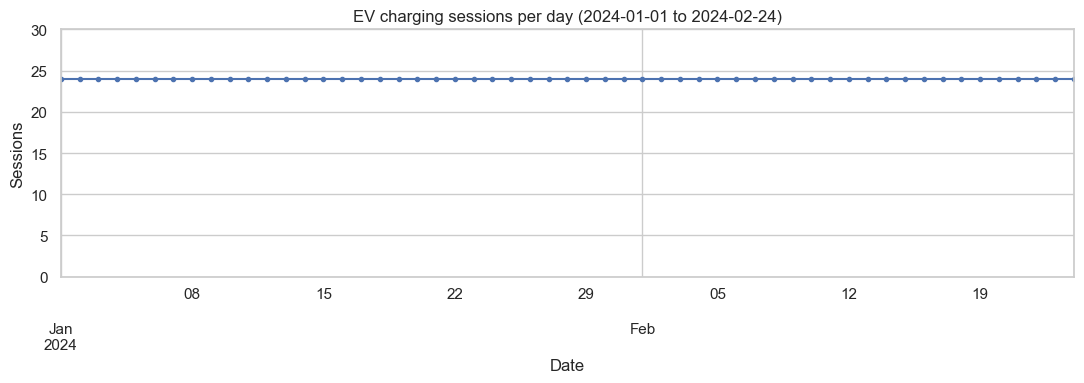

sessions/day: min 24, max 24, distinct values 1


In [32]:
daily = data.set_index("start_time").resample("D").size()

plt.figure(figsize=(11, 4))
daily.plot(marker="o", ms=3)
plt.title("EV charging sessions per day (2024-01-01 to 2024-02-24)")
plt.xlabel("Date")
plt.ylabel("Sessions")
plt.ylim(0, 30)
plt.tight_layout()
plt.show()

print(f"sessions/day: min {daily.min()}, max {daily.max()}, distinct values {daily.nunique()}")

In [33]:
# Sessions per (calendar date, hour) — how many rows share each slot?
per_slot = data.groupby([data["start_time"].dt.date, data["hour"]]).size()
per_slot.value_counts()

1    1320
Name: count, dtype: int64

**Observations**

* Every single day has **exactly 24 sessions**, and every (date, hour) slot has
  **exactly one** session. The data is a perfect 55 x 24 grid: one row per hour for
  every hour from 2024-01-01 00:00 to 2024-02-24 23:00, with no gaps and no duplicates.
* Session *count* therefore has zero variance — there is nothing to forecast in the
  number of sessions. The demand module must instead forecast **energy per hour**
  (`energy_kwh` aggregated to the hour), which does vary from row to row.
* This grid structure is an artefact of how the file was generated, not a property of
  real charging networks. It is stated plainly in the demand notebook and the README.

### 5.2 When during the day is energy drawn?

> **Peak period**
>
> In a real network the peak period is the block of hours that carries a
> disproportionate share of load. Operators size staff and grid capacity around it, and
> the recommendation engine steers users toward quieter windows. Because session count
> here is flat, we look at **energy per hour** instead of session count.

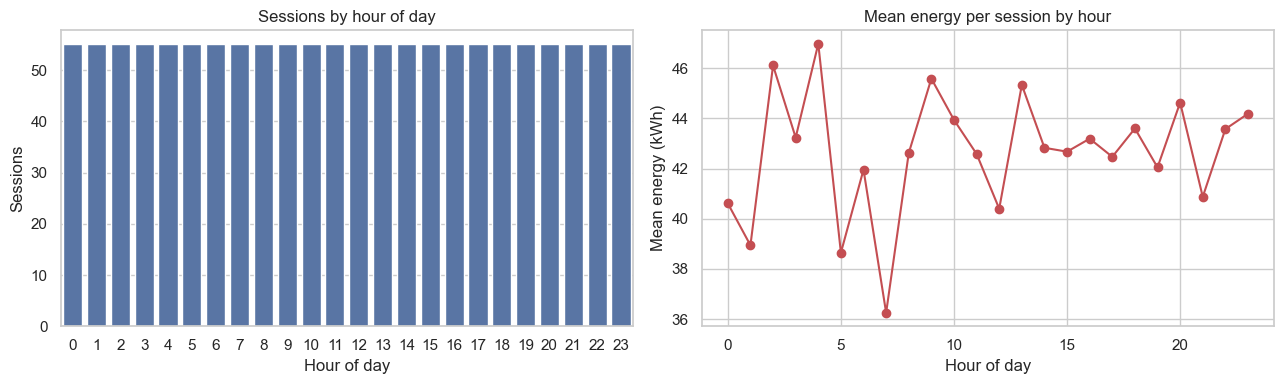

mean energy by hour: min 36.2, max 47.0 kWh


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x="hour", data=data, color="#4C72B0", ax=axes[0])
axes[0].set_title("Sessions by hour of day")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Sessions")

hourly_energy = data.groupby("hour")["energy_kwh"].mean()
hourly_energy.plot(marker="o", ax=axes[1], color="#C44E52")
axes[1].set_title("Mean energy per session by hour")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Mean energy (kWh)")

plt.tight_layout()
plt.show()

print(f"mean energy by hour: min {hourly_energy.min():.1f}, max {hourly_energy.max():.1f} kWh")

**Observations**

* Sessions per hour are **exactly uniform** — 55 in every hour bucket — by construction
  of the grid.
* Mean energy per hour varies between about 36 and 47 kWh across the 24 hours with no
  smooth daily shape. With only 55 sessions per hour bucket that swing is consistent with
  sampling noise, not a commute pattern.
* "Hour of day" will be a weak predictor. We keep it because the pipeline and dashboard
  need a time axis, but we do not expect it to carry a model.

### 5.3 Weekday versus weekend

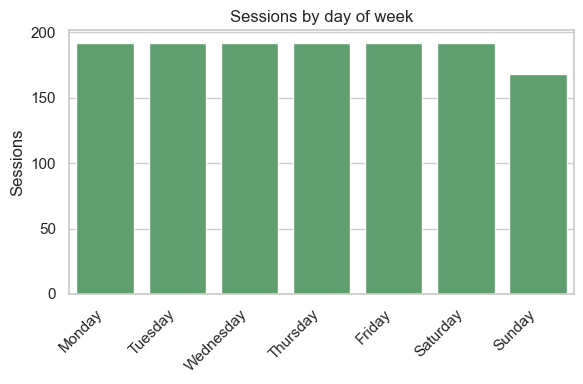

,count,mean
is_weekend,,
0,906,42.063815
1,348,44.150497


In [35]:
plt.figure(figsize=(6, 4))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(x="day_name", data=data, order=order, color="#55A868")
plt.title("Sessions by day of week")
plt.xlabel("")
plt.ylabel("Sessions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

data.groupby("is_weekend")["energy_kwh"].agg(["count", "mean"])

**Observations**

* Session counts per weekday just track how many times that weekday occurs in the
  55-day window (7-8 occurrences x 24 sessions), a direct consequence of the hourly grid
  — not a behavioural signal.
* Mean energy per session is nearly identical on weekdays and weekends. There is no
  day-type split in this data.

### 5.4 How is energy consumed distributed, and does it differ by vehicle?

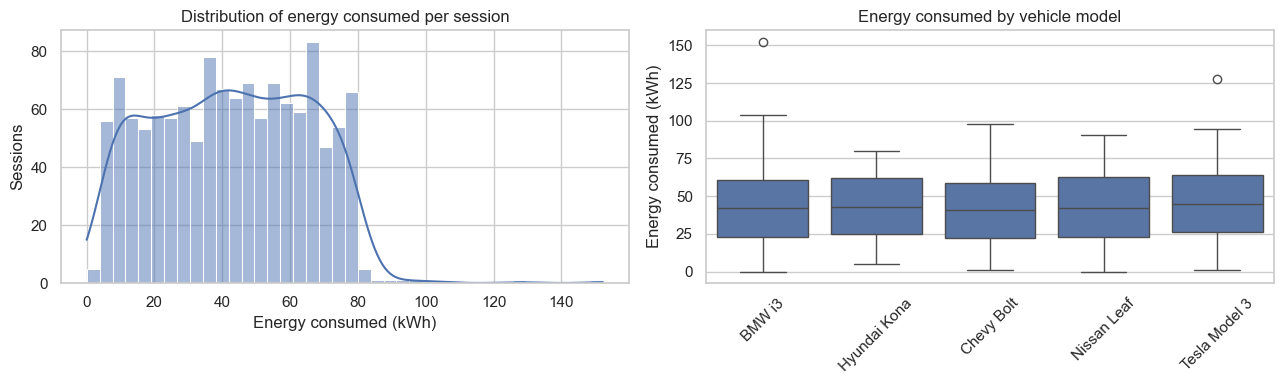

,mean,50%,max
vehicle_model,,,
BMW i3,42.450042,42.375861,152.238758
Chevy Bolt,40.739926,41.089111,97.667765
Hyundai Kona,42.834434,42.918937,79.972672
Nissan Leaf,42.505048,41.993262,90.235504
Tesla Model 3,44.518325,44.758667,127.757474


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data["energy_kwh"].dropna(), bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of energy consumed per session")
axes[0].set_xlabel("Energy consumed (kWh)")
axes[0].set_ylabel("Sessions")

sns.boxplot(x="vehicle_model", y="energy_kwh", data=data, ax=axes[1])
axes[1].set_title("Energy consumed by vehicle model")
axes[1].set_xlabel("")
axes[1].set_ylabel("Energy consumed (kWh)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

data.groupby("vehicle_model")["energy_kwh"].describe()[["mean", "50%", "max"]]

**Observations**

* Energy per session is spread broadly between roughly 0 and 85 kWh, centred near
  43 kWh (median 43, standard deviation 22), with a thin tail reaching ~150 kWh — those
  high values are the rows that later trip the "energy exceeds capacity" flag.
* The five vehicle models have **near-identical** energy distributions (every model's
  mean sits between 41 and 45 kWh). Vehicle model, on its own, barely separates energy
  demand in this data.
* The wide, flat distribution and weak grouping are why the energy regressor's R² will be
  modest — there is limited structure to learn.

### 5.5 How long do sessions actually run?

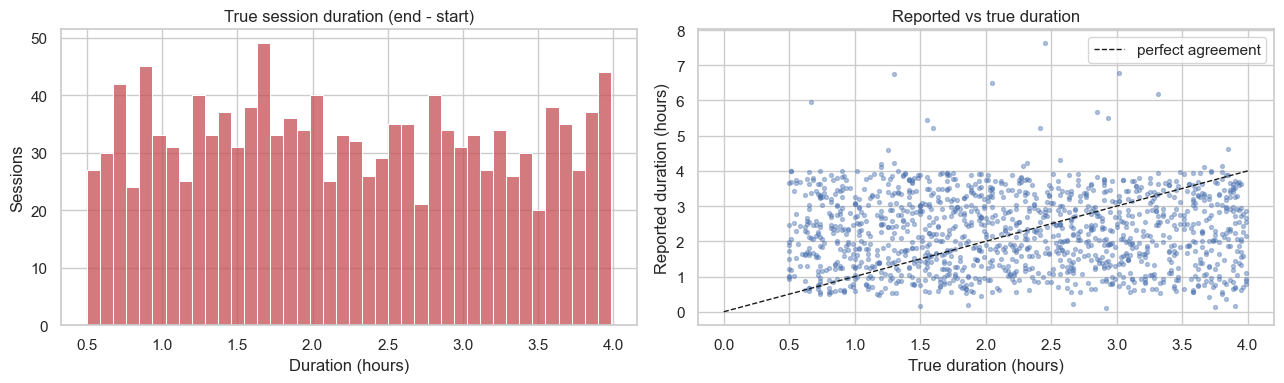

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data["duration_hours"], bins=40, ax=axes[0], color="#C44E52")
axes[0].set_title("True session duration (end - start)")
axes[0].set_xlabel("Duration (hours)")
axes[0].set_ylabel("Sessions")

axes[1].scatter(data["duration_hours"], data["duration_hours_reported"], s=8, alpha=0.4)
axes[1].plot([0, 4], [0, 4], "k--", lw=1, label="perfect agreement")
axes[1].set_title("Reported vs true duration")
axes[1].set_xlabel("True duration (hours)")
axes[1].set_ylabel("Reported duration (hours)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Observations**

* True durations are spread almost uniformly between 0.5 and 4 hours — again no natural
  clustering.
* The reported-vs-true scatter is a **shapeless cloud** with no relationship to the
  diagonal. The file's duration column cannot be used as a feature or a label; the
  duration model targets the timestamp-derived `duration_hours`.

### 5.6 Which charger types are used, and how do they relate to energy and cost?

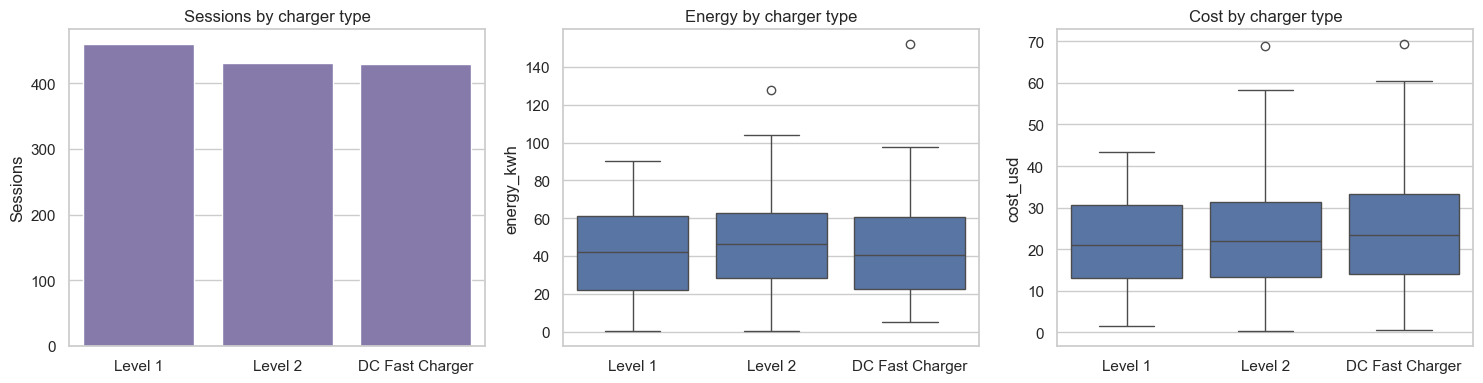

,energy_kwh,cost_usd,charging_rate_kw
charger_type,,,
DC Fast Charger,41.293755,23.604849,25.554545
Level 1,41.608211,21.657563,26.000305
Level 2,45.084983,22.452153,26.330085


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x="charger_type", data=data,
              order=["Level 1", "Level 2", "DC Fast Charger"], ax=axes[0], color="#8172B2")
axes[0].set_title("Sessions by charger type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sessions")

sns.boxplot(x="charger_type", y="energy_kwh", data=data,
            order=["Level 1", "Level 2", "DC Fast Charger"], ax=axes[1])
axes[1].set_title("Energy by charger type")
axes[1].set_xlabel("")

sns.boxplot(x="charger_type", y="cost_usd", data=data,
            order=["Level 1", "Level 2", "DC Fast Charger"], ax=axes[2])
axes[2].set_title("Cost by charger type")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

data.groupby("charger_type")[["energy_kwh", "cost_usd", "charging_rate_kw"]].mean()

**Observations**

* The three charger types are used in roughly equal numbers.
* Energy and cost distributions barely shift across charger types — in a real network,
  DC fast chargers would show higher energy and cost per session. Another sign the
  columns were sampled independently of one another.
* `charging_rate_kw` also does not rise with charger speed, which is physically wrong and
  contributes to the power-consistency flag.

### 5.7 Does behaviour differ by city?

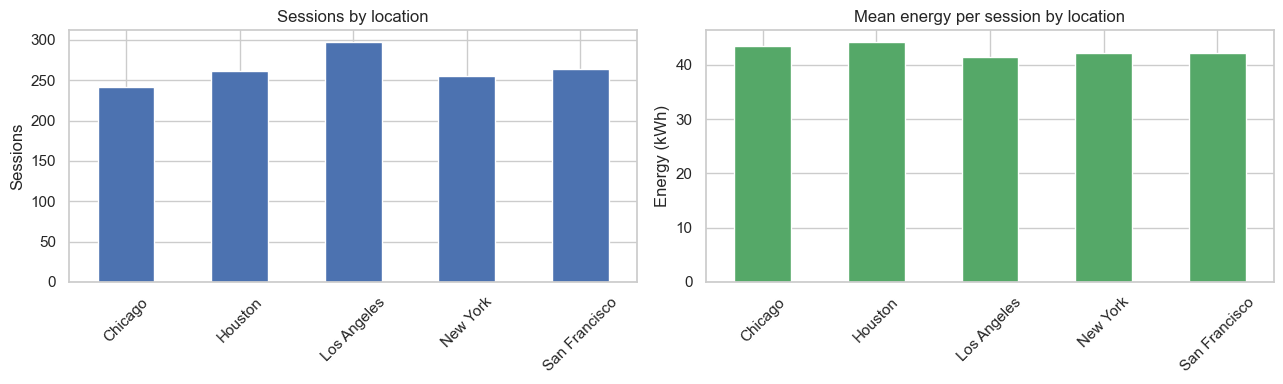

,sessions,mean_energy_kwh,mean_cost_usd,mean_duration_h
location,,,,
Chicago,242,43.49,23.72,2.21
Houston,262,44.13,22.09,2.31
Los Angeles,297,41.39,22.54,2.23
New York,255,42.23,22.50,2.20
San Francisco,264,42.16,21.99,2.18


In [39]:
loc_summary = data.groupby("location").agg(
    sessions=("user_id", "size"),
    mean_energy_kwh=("energy_kwh", "mean"),
    mean_cost_usd=("cost_usd", "mean"),
    mean_duration_h=("duration_hours", "mean"),
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
loc_summary["sessions"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Sessions by location")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sessions")
axes[0].tick_params(axis="x", rotation=45)

loc_summary["mean_energy_kwh"].plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Mean energy per session by location")
axes[1].set_xlabel("")
axes[1].set_ylabel("Energy (kWh)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
loc_summary

**Observations**

* The five cities carry similar session counts (roughly 240–300 each).
* Mean energy, cost and duration are within a few percent of each other across cities.
* Location will mostly matter as a *grouping* dimension for the dashboard and the
  location-split demand forecast, not as a strong predictor of any single session's
  outcome.

### 5.8 Charging cost

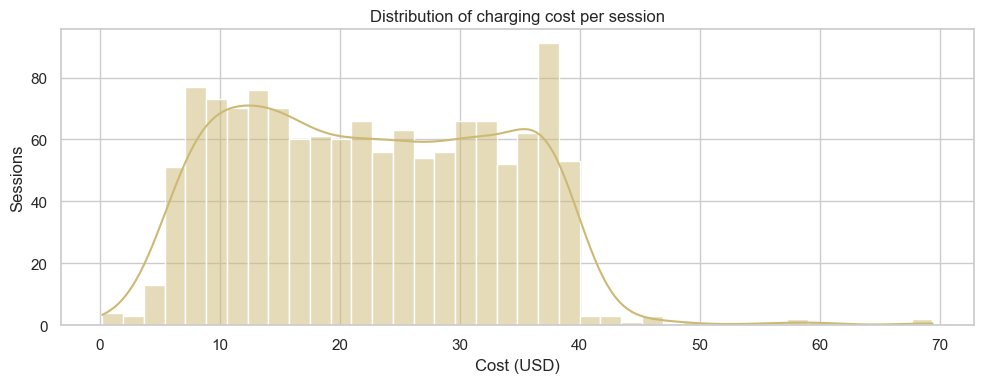

count    1320.00
mean       22.55
std        10.75
min         0.23
25%        13.37
50%        22.08
75%        31.65
max        69.41
Name: cost_usd, dtype: float64
correlation(cost, energy) = -0.008


In [40]:
plt.figure(figsize=(10, 4))
sns.histplot(data["cost_usd"], bins=40, kde=True, color="#CCB974")
plt.title("Distribution of charging cost per session")
plt.xlabel("Cost (USD)")
plt.ylabel("Sessions")
plt.tight_layout()
plt.show()

print(data["cost_usd"].describe().round(2))
corr_ec = data[["cost_usd", "energy_kwh"]].corr().iloc[0, 1]
print(f"correlation(cost, energy) = {corr_ec:.3f}")

**Observations**

* Cost spans about \$0 to \$70 per session with a broad, roughly symmetric spread and a
  median near \$22.
* Cost and energy are **uncorrelated** (r near -0.01). In a real tariff, cost would track
  energy closely; here it does not, so cost is treated as an independent reported
  quantity, not a derived one.

### 5.9 State of charge: start, end, and the swing

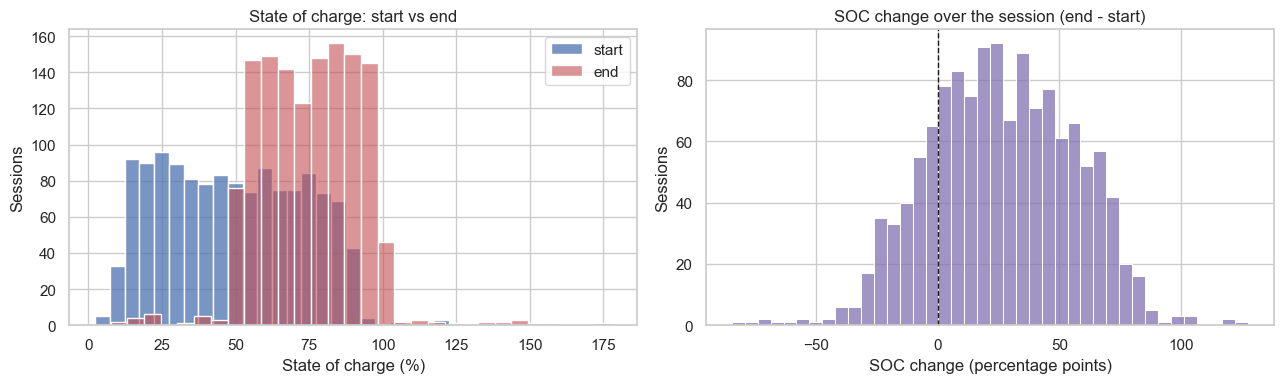

sessions where SOC did not increase: 268 (20.3%)


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data["soc_start_pct"], bins=30, color="#4C72B0", label="start", ax=axes[0])
sns.histplot(data["soc_end_pct"], bins=30, color="#C44E52", label="end", ax=axes[0], alpha=0.6)
axes[0].set_title("State of charge: start vs end")
axes[0].set_xlabel("State of charge (%)")
axes[0].set_ylabel("Sessions")
axes[0].legend()

sns.histplot(data["soc_delta_pct"], bins=40, ax=axes[1], color="#8172B2")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_title("SOC change over the session (end - start)")
axes[1].set_xlabel("SOC change (percentage points)")
axes[1].set_ylabel("Sessions")

plt.tight_layout()
plt.show()

print(f"sessions where SOC did not increase: {(data['soc_delta_pct'] <= 0).sum()} "
      f"({(data['soc_delta_pct'] <= 0).mean():.1%})")

**Observations**

* Start and end SOC are both spread across the whole 0–100 range with similar shapes.
* The SOC change is centred near zero and is **negative for about 20% of sessions** —
  the battery lost charge while ostensibly charging. Those rows carry the
  `flag_soc_not_increasing` flag and are prime anomaly candidates.
* 32 SOC readings fall outside 0–100, some far outside (start values range from about
  2 to 152), and carry the `flag_soc_out_of_range` flag.

### 5.10 How do the numeric features correlate?

A correlation heatmap shows which measurements move together. On a well-formed dataset we
would expect energy, duration, rate and cost to form a tight block. Here we expect the
opposite, and that expectation is the finding.

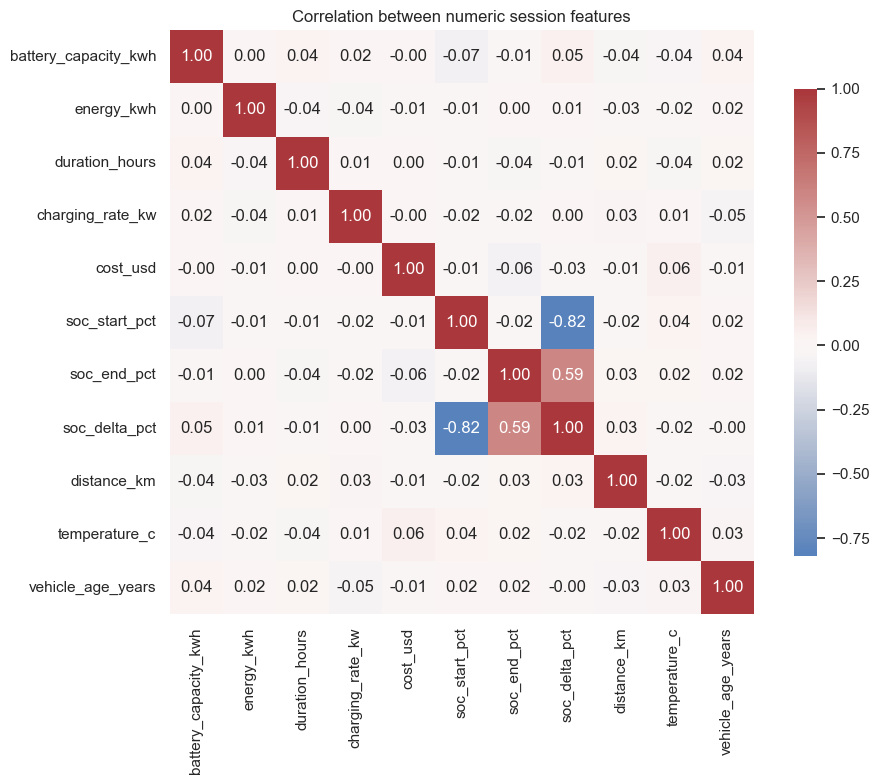

In [42]:
num_cols = ["battery_capacity_kwh", "energy_kwh", "duration_hours", "charging_rate_kw",
            "cost_usd", "soc_start_pct", "soc_end_pct", "soc_delta_pct", "distance_km",
            "temperature_c", "vehicle_age_years"]
corr = data[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation between numeric session features")
plt.tight_layout()
plt.show()

**Observations**

* Almost every off-diagonal cell is near zero. Energy, duration, rate and cost are
  mutually **uncorrelated** — the physical relationships that should link them are absent.
* The only meaningful correlations are the arithmetic ones we created ourselves
  (`soc_delta_pct` with the two SOC columns).
* This heatmap is the clearest single picture of why model metrics will be modest: with
  no linear structure among the drivers, a linear model has almost nothing to fit, and
  tree models will only pick up faint non-linear traces.

### 5.11 A first look at candidate session segments

Phase 2 clusters sessions into behavioural archetypes. As a preview, we scale three
interpretable features — energy, duration and distance — and colour a 2-D view by
`charger_type`. This is not the real clustering, just a check that any structure exists.

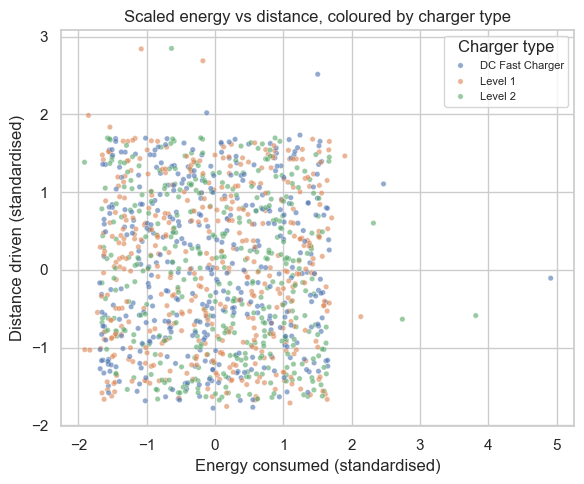

In [43]:
from sklearn.preprocessing import StandardScaler

seg_cols = ["energy_kwh", "duration_hours", "distance_km"]
seg = data[seg_cols].dropna()
scaled = StandardScaler().fit_transform(seg)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=scaled[:, 0], y=scaled[:, 2],
                hue=data.loc[seg.index, "charger_type"], s=15, alpha=0.6)
plt.title("Scaled energy vs distance, coloured by charger type")
plt.xlabel("Energy consumed (standardised)")
plt.ylabel("Distance driven (standardised)")
plt.legend(title="Charger type", fontsize=8)
plt.tight_layout()
plt.show()

**Observations**

* The scatter is a single diffuse blob with no visually separable groups and no colour
  structure.
* K-Means will still return `k` clusters, but we should expect them to be *soft* slices
  of a continuum (low / medium / high energy) rather than crisp archetypes, and the
  silhouette score will be low. The Phase-2 notebook will report this honestly.

## 6. Conclusion

**Insights**

* The dataset is **1,320 sessions, one per user, across 462 stations and 5 cities**, over
  55 days. Structurally this forces session-level (not user-level) behaviour analysis and
  network-level (not station-level) demand forecasting.
* The timestamps form a **perfect 55 x 24 hourly grid** — exactly one session per hour,
  every hour, with no gaps or duplicates. Session count has no variance, so the demand
  module forecasts **energy per hour**, not number of sessions.
* It was generated column by column. The cross-column physics does not hold: reported
  duration disagrees with the timestamps on ~72% of rows, `rate × duration` disagrees
  with energy on ~59%, SOC-implied energy disagrees on ~66%, energy exceeds battery
  capacity on 190 rows, and SOC fails to increase on 268.
* The numeric features are mutually uncorrelated. There is little linear structure for
  any regressor to exploit, so Phase-2 metrics will be modest by construction.
* Missing values are limited and independent: 66 each in `energy_kwh`, `charging_rate_kw`
  and `distance_km`.
* `Time of Day` and `Day of Week` in the file do not match the timestamps and are
  discarded in favour of derived calendar features.

**Suggestions**

* Keep all 1,320 rows. Carry the nine validation flags forward as first-class columns;
  they are the supervision signal for the anomaly module and the honesty section of the
  final report.
* Use `duration_hours` (from timestamps) everywhere; never the reported column.
* Defer missing-value imputation to each model's own prep step, dropping a row only when
  that model's target is null.
* Frame every model's evaluation against a simple baseline and report the gap, not just
  the absolute score.
* State the data's limitations prominently in the dashboard and README so the modest
  metrics read as honesty, not weakness.

**Possible Next Steps**

* `02_feature_engineering.ipynb` — walk through the feature build in ML-notebook style
  and persist `data/processed/sessions_clean.parquet`.
* `03`–`04` — energy and duration regressors (baseline → linear → random forest → XGBoost).
* `05` — session segmentation with K-Means and cluster profiling.
* `06` — anomaly detection with Isolation Forest, reconciled against the validation flags.
* `07` — network-level demand forecasting with walk-forward validation.